In [ ]:
import os
from kan import KAN
import matplotlib.pyplot as plt
import scipy.io
from sklearn.datasets import make_moons
import torch
import numpy as np

In [15]:
device = torch.device('mps')
print(device)

mps


In [31]:
data_dir = './Test Subject Preprocessed_14'

session1_files = sorted([f for f in os.listdir(data_dir) if f.startswith('Processed_data_received_') and '_S1.mat' in f])
session2_files = sorted([f for f in os.listdir(data_dir) if f.startswith('Processed_data_received_') and '_S2.mat' in f])

x_train = None
x_test = None

for i, (session1_file, session2_file) in enumerate(zip(session1_files, session2_files)):
    session1_data = scipy.io.loadmat(os.path.join(data_dir, session1_file))
    session2_data = scipy.io.loadmat(os.path.join(data_dir, session2_file))

    session1_array = np.array(list(session1_data.values())[3])  
    session2_array = np.array(list(session2_data.values())[3])
    
    if i == 0:
        x_train = session1_array
        x_test = session2_array
    else:
        x_train = np.concatenate((x_train, session1_array), axis=2)
        x_test = np.concatenate((x_test, session2_array), axis=2)
        
x_train = x_train.transpose(2, 0, 1)  
x_train = x_train.reshape(720, -1)  

x_test = x_test.transpose(2, 0, 1) 
x_test = x_test.reshape(720, -1) 
        
# Initialize labels
lab_train = []
lab_test = []

# Generate labels
k = 1
for j in range(1, 19): 
    for i in range(40):
        lab_train.append(j)
        lab_test.append(j)
        k += 1

lab_train = np.array(lab_train).reshape(-1, 1)
lab_test = np.array(lab_test).reshape(-1, 1)

labels = lab_train
labels_test = lab_test


In [32]:
print(x_train.shape)
print(x_test.shape)
print(labels.shape)
print(labels_test.shape)

(720, 1092)
(720, 1092)
(720, 1)
(720, 1)


In [33]:
dataset = {}
dataset['train_input'] = torch.from_numpy(x_train).type(dtype=torch.float32).to(device)
dataset['test_input'] = torch.from_numpy(x_test).type(dtype=torch.float32).to(device)
dataset['train_label'] = torch.from_numpy(labels).type(torch.long).to(device)
dataset['test_label'] = torch.from_numpy(labels_test).type(torch.long).to(device)

In [36]:
print("Train label shape:", dataset['train_label'].shape)
print("Train label dtype:", dataset['train_label'].dtype)

Train label shape: torch.Size([720, 1])
Train label dtype: torch.int64


In [47]:
model = KAN(width=[1092, 256, 128, 18], grid=3, k=3, noise_scale=0.3, seed=2024, device=device)

dataset['train_label'] = dataset['train_label'].squeeze()  
dataset['test_label'] = dataset['test_label'].squeeze()   

def train_acc():
    with torch.no_grad():
        batch_size = 128
        accs = []
        for i in range(0, len(dataset['train_input']), batch_size):
            batch_x = dataset['train_input'][i:i+batch_size]
            batch_y = dataset['train_label'][i:i+batch_size]
            pred = torch.argmax(model(batch_x), dim=1)
            acc = torch.mean((pred == batch_y).type(torch.float32))
            accs.append(acc)
    return torch.mean(torch.stack(accs))

def test_acc():
    batch_size = 32
    accs = []
    for i in range(0, len(dataset['test_input']), batch_size):
        batch_x = dataset['test_input'][i:i+batch_size]
        batch_y = dataset['test_label'][i:i+batch_size] 
        pred = torch.argmax(model(batch_x), dim=1)
        acc = torch.mean((pred == batch_y).type(torch.float32))
        accs.append(acc)
    return torch.mean(torch.stack(accs))

checkpoint directory created: ./model
saving model version 0.0


In [51]:
results = model.fit(
    dataset,
    opt="Adam",
    steps=250,
    batch=32,
    lr=0.001,
    metrics=(train_acc, test_acc),
    loss_fn=torch.nn.CrossEntropyLoss(),
    update_grid=False
)

| train_loss: 3.45e-01 | test_loss: 1.78e+00 | reg: 4.54e+03 | : 100%|█| 250/250 [01:35<00:00,  2.63


saving model version 0.1


KeyboardInterrupt: 

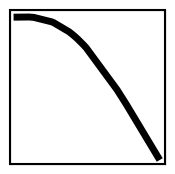

In [52]:
model.plot()

In [53]:
print(test_acc())

KeyboardInterrupt: 